# AI Car Insurance Advisor - Sprint 1 Baseline (Google Colab)

This notebook is a **working Sprint 1 proof of concept** for the Australia-based AI Car Insurance Advisor project.

It focuses on the must-have backend logic only:
- load the approved policy catalog
- create a synthetic training set for a baseline model
- train a **risk score model**
- train a **premium estimation model**
- parse simple uploaded/plain-text insurance details
- validate fields and route incomplete cases to **manual review**
- recommend **top-3 policies**
- compare policies
- explain why a policy was recommended

**Important note:** this notebook avoids UI/UX on purpose for Sprint 1. The goal here is a clean, working, easy-to-extend baseline.


## 1. Install and import packages

This notebook is designed to run in **Google Colab**.
If the dataset file is not already present, you can upload it in the next cell.


In [4]:
# If needed in Colab, uncomment and run the next line once:
# !pip -q install pandas numpy scikit-learn joblib matplotlib

import os
import re
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


## 2. Load the policy catalog

Expected file name:
`australian_car_insurance_policies_readable_headers.csv`

This notebook first looks for the file locally.  
If it cannot find it, it will ask for a Colab upload.


In [5]:
DATASET_FILENAME = "australian_car_insurance_policies_readable_headers.csv"

def locate_dataset(filename=DATASET_FILENAME):
    candidate_paths = [
        Path(f"/content/{filename}"),
        Path(f"/mnt/data/{filename}"),
        Path(filename),
    ]
    for path in candidate_paths:
        if path.exists():
            return str(path)

    try:
        from google.colab import files
        print(f"Could not find {filename}. Please upload it now.")
        uploaded = files.upload()
        if filename in uploaded:
            return f"/content/{filename}"
        if len(uploaded) == 1:
            only_file = list(uploaded.keys())[0]
            return f"/content/{only_file}"
    except Exception:
        pass

    raise FileNotFoundError(
        f"Could not find {filename}. Upload the file to Colab or place it beside the notebook."
    )

catalog_path = locate_dataset()
print("Using dataset:", catalog_path)

policy_catalog_raw = pd.read_csv(catalog_path)
print("Shape:", policy_catalog_raw.shape)
policy_catalog_raw.head()


Using dataset: /content/australian_car_insurance_policies_readable_headers.csv
Shape: (74, 11)


,Policy ID,Insurer,Product Name,Cover Family,Product Tier,State Specific,Own Vehicle Cover,Third Party Property Cover,Fire/Theft Cover,Injury Cover,Official URL
0,ALLIANZ_COMP,Allianz,Comprehensive Car Insurance,comprehensive,standard,general,yes,yes,yes,no,https://www.allianz.com.au/car-insurance/compr...
1,ALLIANZ_COMP_ESS,Allianz,Comprehensive Car Insurance Essentials,comprehensive,basics,general,yes,yes,yes,no,https://www.allianz.com.au/car-insurance/compr...
2,ALLIANZ_TPPD,Allianz,Third Party Property Damage Car Insurance,third_party_property_damage,standard,general,no,yes,no,no,https://www.allianz.com.au/car-insurance/third...
3,ALLIANZ_CTP_NSW,Allianz,CTP Insurance,ctp_or_mai,standard,NSW,no,no,no,yes,https://www.allianz.com.au/ctp-insurance/nsw.html
4,ALLIANZ_CTP_QLD,Allianz,CTP Insurance,ctp_or_mai,standard,QLD,no,no,no,yes,https://www.allianz.com.au/ctp-insurance/qld.html


## 3. Clean and enrich the catalog

We keep the original policy rows, then add a few simple engineered fields:
- numeric coverage flags
- state applicability
- coverage score
- tier multiplier
- base premium hint

These are baseline features only and are easy to improve later.


In [6]:
def prepare_policy_catalog(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.columns = [c.strip() for c in out.columns]

    yes_no_map = {"yes": 1.0, "no": 0.0, "optional": 0.5}
    coverage_cols = [
        "Own Vehicle Cover",
        "Third Party Property Cover",
        "Fire/Theft Cover",
        "Injury Cover",
    ]
    for col in coverage_cols:
        out[col] = (
            out[col]
            .astype(str)
            .str.strip()
            .str.lower()
            .map(yes_no_map)
            .fillna(0.0)
        )

    tier_map = {
        "basics": 0.85,
        "standard": 1.00,
        "plus": 1.08,
        "premium": 1.20,
        "low_km": 0.90,
        "fire_theft_option": 0.95,
    }
    base_family_price = {
        "ctp_or_mai": 180,
        "third_party_property_damage": 550,
        "third_party_fire_theft": 700,
        "comprehensive": 1100,
    }

    out["state_specific_clean"] = out["State Specific"].fillna("general").astype(str).str.upper()
    out.loc[out["state_specific_clean"] == "GENERAL", "state_specific_clean"] = "general"

    out["tier_multiplier"] = out["Product Tier"].map(tier_map).fillna(1.0)
    out["base_premium_hint"] = out["Cover Family"].map(base_family_price).fillna(800) * out["tier_multiplier"]

    out["coverage_score"] = (
        40 * out["Own Vehicle Cover"]
        + 25 * out["Third Party Property Cover"]
        + 20 * out["Fire/Theft Cover"]
        + 15 * out["Injury Cover"]
    )
    out["is_state_limited"] = (out["state_specific_clean"] != "general").astype(int)

    return out

policy_catalog = prepare_policy_catalog(policy_catalog_raw)
policy_catalog.head()


,Policy ID,Insurer,Product Name,Cover Family,Product Tier,State Specific,Own Vehicle Cover,Third Party Property Cover,Fire/Theft Cover,Injury Cover,Official URL,state_specific_clean,tier_multiplier,base_premium_hint,coverage_score,is_state_limited
0,ALLIANZ_COMP,Allianz,Comprehensive Car Insurance,comprehensive,standard,general,1.0,1.0,1.0,0.0,https://www.allianz.com.au/car-insurance/compr...,general,1.00,1100.0,85.0,0
1,ALLIANZ_COMP_ESS,Allianz,Comprehensive Car Insurance Essentials,comprehensive,basics,general,1.0,1.0,1.0,0.0,https://www.allianz.com.au/car-insurance/compr...,general,0.85,935.0,85.0,0
2,ALLIANZ_TPPD,Allianz,Third Party Property Damage Car Insurance,third_party_property_damage,standard,general,0.0,1.0,0.0,0.0,https://www.allianz.com.au/car-insurance/third...,general,1.00,550.0,25.0,0
3,ALLIANZ_CTP_NSW,Allianz,CTP Insurance,ctp_or_mai,standard,NSW,0.0,0.0,0.0,1.0,https://www.allianz.com.au/ctp-insurance/nsw.html,NSW,1.00,180.0,15.0,1
4,ALLIANZ_CTP_QLD,Allianz,CTP Insurance,ctp_or_mai,standard,QLD,0.0,0.0,0.0,1.0,https://www.allianz.com.au/ctp-insurance/qld.html,QLD,1.00,180.0,15.0,1


## 4. Create a synthetic training dataset for Sprint 1

Because Sprint 1 only needs a **working recommendation baseline**, we generate a realistic synthetic customer dataset using project-aligned logic:
- age, claims, kilometres, usage, parking, vehicle value, etc.
- rule-driven risk score target
- rule-driven expected premium target
- preferred cover family target

Later sprints can replace this with stronger real/synthetic training data.


In [7]:
STATES = ["NSW", "VIC", "QLD", "WA", "SA", "ACT", "TAS", "NT"]
VEHICLE_TYPES = ["sedan", "suv", "hatch", "ute", "electric", "luxury", "sports"]
USAGE_TYPES = ["private", "commute", "business", "rideshare"]
PARKING_TYPES = ["garage", "street", "carport"]
COVER_PREFS = ["basic", "balanced", "premium"]

def generate_synthetic_customers(n=6000, seed=42):
    rng = np.random.default_rng(seed)
    rows = []

    for i in range(n):
        age = int(rng.integers(18, 80))
        years_licensed = max(0, age - 17 - int(rng.integers(0, 6)))
        state = rng.choice(STATES, p=np.array([0.31, 0.25, 0.20, 0.10, 0.06, 0.03, 0.03, 0.02]))

        vehicle_type = rng.choice(
            VEHICLE_TYPES,
            p=np.array([0.26, 0.24, 0.14, 0.12, 0.08, 0.08, 0.08]),
        )
        usage_type = rng.choice(
            USAGE_TYPES,
            p=np.array([0.42, 0.35, 0.15, 0.08]),
        )
        parking_type = rng.choice(
            PARKING_TYPES,
            p=np.array([0.50, 0.30, 0.20]),
        )

        vehicle_year = int(rng.integers(2003, 2026))
        vehicle_age = 2026 - vehicle_year

        annual_km = int(np.clip(rng.normal(14000, 6000), 3000, 40000))
        vehicle_value = float(np.clip(rng.normal(24000, 14000), 4000, 90000))
        if vehicle_type in ["electric", "luxury", "sports"]:
            vehicle_value *= float(rng.uniform(1.2, 1.8))

        claims_last_5y = int(
            np.clip(
                rng.poisson(
                    0.35 + (age < 25) * 0.45 + (usage_type in ["business", "rideshare"]) * 0.25
                ),
                0,
                6,
            )
        )
        at_fault_claims = int(np.clip(rng.binomial(claims_last_5y, 0.60) if claims_last_5y > 0 else 0, 0, 6))
        incidents_last_3y = int(
            np.clip(
                rng.poisson(0.25 + (age < 25) * 0.40 + (usage_type == "rideshare") * 0.35),
                0,
                5,
            )
        )
        licence_suspensions = int(
            rng.binomial(1, 0.02 + 0.04 * (age < 23) + 0.03 * (usage_type == "rideshare"))
        )
        no_claim_years = max(0, min(10, int(rng.integers(0, 11)) - claims_last_5y))
        has_security = int(rng.binomial(1, 0.65 if parking_type == "garage" else 0.35))
        young_driver = int(age < 25)

        budget_preference = rng.choice(["low", "medium", "high"], p=np.array([0.34, 0.45, 0.21]))
        cover_preference = rng.choice(COVER_PREFS, p=np.array([0.28, 0.48, 0.24]))

        # Synthetic risk target
        risk_score = (
            25
            + 18 * young_driver
            + 6 * (usage_type in ["business", "rideshare"])
            + 7 * (usage_type == "rideshare")
            + 5 * (parking_type == "street")
            + 4 * claims_last_5y
            + 5 * at_fault_claims
            + 3 * incidents_last_3y
            + 15 * licence_suspensions
            + 0.00018 * vehicle_value
            + 0.00070 * annual_km
            + 4 * (vehicle_type in ["luxury", "sports"])
            - 1.4 * min(no_claim_years, 8)
            - 3 * has_security
        )
        if cover_preference == "premium":
            risk_score += 1.5

        risk_score = float(np.clip(risk_score + rng.normal(0, 4), 5, 98))

        # Preferred cover family target
        if vehicle_value >= 30000 or vehicle_age <= 6 or cover_preference == "premium":
            preferred_cover_family = "comprehensive"
        elif vehicle_value >= 12000 or claims_last_5y == 0 or cover_preference == "balanced":
            preferred_cover_family = "third_party_fire_theft"
        else:
            preferred_cover_family = "third_party_property_damage"

        # Synthetic premium target
        budget_factor = {"low": 0.90, "medium": 1.00, "high": 1.12}[budget_preference]
        usage_factor = {"private": 1.00, "commute": 1.05, "business": 1.12, "rideshare": 1.22}[usage_type]
        type_factor = {
            "sedan": 1.00,
            "suv": 1.07,
            "hatch": 0.95,
            "ute": 1.03,
            "electric": 1.12,
            "luxury": 1.22,
            "sports": 1.28,
        }[vehicle_type]
        cover_factor = {
            "third_party_property_damage": 0.72,
            "third_party_fire_theft": 0.88,
            "comprehensive": 1.00,
        }[preferred_cover_family]

        base = 250 + 10 * risk_score + 0.012 * vehicle_value + 0.010 * annual_km
        expected_premium = base * usage_factor * type_factor * budget_factor * cover_factor
        expected_premium = float(np.clip(expected_premium + rng.normal(0, 120), 350, 6500))

        rows.append(
            {
                "customer_id": f"CUST_{i:05d}",
                "age": age,
                "years_licensed": years_licensed,
                "state": state,
                "vehicle_type": vehicle_type,
                "usage_type": usage_type,
                "parking_type": parking_type,
                "vehicle_year": vehicle_year,
                "vehicle_age": vehicle_age,
                "vehicle_value": round(vehicle_value, 2),
                "annual_km": annual_km,
                "claims_last_5y": claims_last_5y,
                "at_fault_claims": at_fault_claims,
                "incidents_last_3y": incidents_last_3y,
                "licence_suspensions": licence_suspensions,
                "no_claim_years": no_claim_years,
                "has_security": has_security,
                "young_driver": young_driver,
                "budget_preference": budget_preference,
                "cover_preference": cover_preference,
                "preferred_cover_family": preferred_cover_family,
                "risk_score_target": round(risk_score, 2),
                "expected_premium_target": round(expected_premium, 2),
            }
        )

    return pd.DataFrame(rows)

synthetic_customers = generate_synthetic_customers(n=6000, seed=42)
print("Synthetic dataset shape:", synthetic_customers.shape)
synthetic_customers.head()


Synthetic dataset shape: (6000, 23)


,customer_id,age,years_licensed,state,vehicle_type,usage_type,parking_type,vehicle_year,vehicle_age,vehicle_value,annual_km,claims_last_5y,at_fault_claims,incidents_last_3y,licence_suspensions,no_claim_years,has_security,young_driver,budget_preference,cover_preference,preferred_cover_family,risk_score_target,expected_premium_target
0,CUST_00000,23,2,VIC,luxury,commute,garage,2015,11,24991.63,14767,1,0,2,0,9,1,1,low,premium,comprehensive,58.94,1461.51
1,CUST_00001,61,42,TAS,luxury,business,garage,2011,15,47937.91,16192,2,1,0,0,3,1,0,medium,basic,comprehensive,63.37,2303.89
2,CUST_00002,27,6,QLD,suv,business,carport,2022,4,36200.00,15312,0,0,0,0,4,1,0,medium,balanced,comprehensive,38.36,1406.89
3,CUST_00003,49,29,NSW,sedan,commute,garage,2022,4,26278.54,11990,0,0,0,0,6,1,0,medium,basic,comprehensive,25.96,838.98
4,CUST_00004,20,2,NSW,suv,private,street,2005,21,32758.27,14951,0,0,1,0,6,0,1,medium,balanced,comprehensive,57.08,1460.40


## 5. Train the baseline models

We train two models:
1. **Risk Score Model** - predicts driver risk
2. **Premium Model** - predicts a baseline premium expectation

For Sprint 1, Random Forest is simple, stable, and works well on mixed tabular data.


In [8]:
feature_cols = [
    "age",
    "years_licensed",
    "state",
    "vehicle_type",
    "usage_type",
    "parking_type",
    "vehicle_year",
    "vehicle_age",
    "vehicle_value",
    "annual_km",
    "claims_last_5y",
    "at_fault_claims",
    "incidents_last_3y",
    "licence_suspensions",
    "no_claim_years",
    "has_security",
    "young_driver",
    "budget_preference",
    "cover_preference",
]

numeric_cols = [c for c in feature_cols if synthetic_customers[c].dtype != "object"]
categorical_cols = [c for c in feature_cols if synthetic_customers[c].dtype == "object"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_cols,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_cols,
        ),
    ]
)

risk_model = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=250,
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1,
        )),
    ]
)

premium_model = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=300,
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1,
        )),
    ]
)

X = synthetic_customers[feature_cols]
y_risk = synthetic_customers["risk_score_target"]
y_premium = synthetic_customers["expected_premium_target"]

X_train, X_test, y_risk_train, y_risk_test, y_premium_train, y_premium_test = train_test_split(
    X, y_risk, y_premium, test_size=0.2, random_state=42
)

risk_model.fit(X_train, y_risk_train)
premium_model.fit(X_train, y_premium_train)

risk_pred = risk_model.predict(X_test)
premium_pred = premium_model.predict(X_test)

print("Risk model MAE:", round(mean_absolute_error(y_risk_test, risk_pred), 3))
print("Risk model R2 :", round(r2_score(y_risk_test, risk_pred), 3))
print("Premium model MAE:", round(mean_absolute_error(y_premium_test, premium_pred), 3))
print("Premium model R2 :", round(r2_score(y_premium_test, premium_pred), 3))


Risk model MAE: 4.407
Risk model R2 : 0.833
Premium model MAE: 144.465
Premium model R2 : 0.828


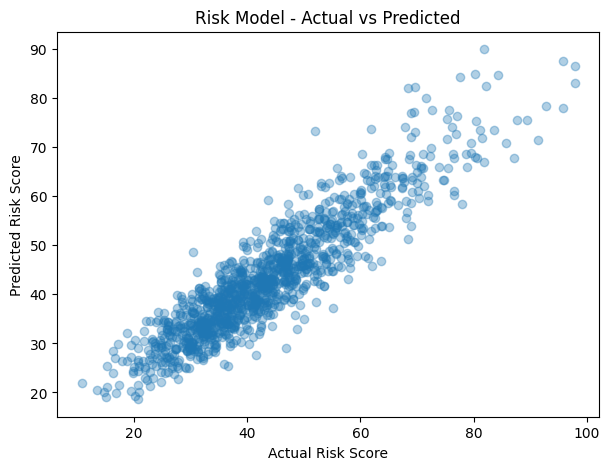

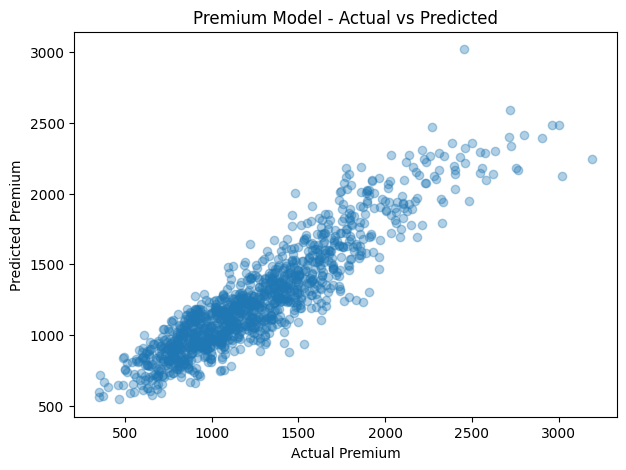

In [9]:
# Quick visual check
plt.figure(figsize=(7, 5))
plt.scatter(y_risk_test, risk_pred, alpha=0.35)
plt.xlabel("Actual Risk Score")
plt.ylabel("Predicted Risk Score")
plt.title("Risk Model - Actual vs Predicted")
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(y_premium_test, premium_pred, alpha=0.35)
plt.xlabel("Actual Premium")
plt.ylabel("Predicted Premium")
plt.title("Premium Model - Actual vs Predicted")
plt.show()


## 6. Helper functions for extraction, validation, scoring and explanation

This is the core application logic for Sprint 1.
It supports:
- simple text extraction from pasted/loaded document text
- manual profile completion
- confidence/validation fallback
- recommendation ranking
- policy comparison
- explanation generation


In [10]:
def parse_bool(value):
    if isinstance(value, bool):
        return int(value)
    if value is None:
        return 0
    value = str(value).strip().lower()
    return int(value in {"1", "true", "yes", "y"})

def extract_fields_from_text(text: str) -> dict:
    text = text or ""
    patterns = {
        "age": r"age[:\s]+(\d{2})",
        "state": r"state[:\s]+([A-Za-z]{2,3})",
        "vehicle_year": r"(?:vehicle year|year)[:\s]+(20\d{2}|19\d{2})",
        "vehicle_value": r"(?:vehicle value|car value|sum insured)[:\s\$,]+([\d,]+(?:\.\d+)?)",
        "annual_km": r"(?:annual km|kilometres|kms per year)[:\s,]+([\d,]+)",
        "claims_last_5y": r"(?:claims last 5y|claims in last 5 years|claims)[:\s]+(\d+)",
        "at_fault_claims": r"(?:at fault claims|at-fault claims)[:\s]+(\d+)",
        "incidents_last_3y": r"(?:incidents last 3y|incidents|traffic incidents)[:\s]+(\d+)",
        "licence_suspensions": r"(?:licence suspensions|license suspensions)[:\s]+(\d+)",
        "no_claim_years": r"(?:no claim years|years no claim bonus)[:\s]+(\d+)",
    }

    extracted = {}
    for field, pattern in patterns.items():
        match = re.search(pattern, text, flags=re.IGNORECASE)
        if match:
            extracted[field] = match.group(1).replace(",", "")

    simple_string_fields = [
        "vehicle_type",
        "usage_type",
        "parking_type",
        "budget_preference",
        "cover_preference",
    ]
    for field in simple_string_fields:
        match = re.search(fr"{field.replace('_', ' ')}[:\s]+([A-Za-z_]+)", text, flags=re.IGNORECASE)
        if match:
            extracted[field] = match.group(1).lower()

    if re.search(r"garage|secure parking", text, flags=re.IGNORECASE):
        extracted["has_security"] = 1

    return extracted

REQUIRED_FIELDS = [
    "age",
    "state",
    "vehicle_year",
    "vehicle_value",
    "annual_km",
    "claims_last_5y",
    "vehicle_type",
    "usage_type",
]

def validate_user_profile(profile: dict) -> dict:
    missing_fields = [f for f in REQUIRED_FIELDS if f not in profile or profile[f] in [None, ""]]
    return {
        "is_valid": len(missing_fields) == 0,
        "missing_fields": missing_fields,
    }

def normalize_user_profile(profile: dict) -> dict:
    p = dict(profile)

    p["state"] = str(p.get("state", "NSW")).upper()
    p["vehicle_type"] = str(p.get("vehicle_type", "sedan")).lower()
    p["usage_type"] = str(p.get("usage_type", "private")).lower()
    p["parking_type"] = str(p.get("parking_type", "garage")).lower()
    p["budget_preference"] = str(p.get("budget_preference", "medium")).lower()
    p["cover_preference"] = str(p.get("cover_preference", "balanced")).lower()

    p["age"] = int(float(p.get("age", 30)))
    p["vehicle_year"] = int(float(p.get("vehicle_year", 2018)))
    p["vehicle_age"] = int(float(p.get("vehicle_age", 2026 - p["vehicle_year"])))
    p["years_licensed"] = int(float(p.get("years_licensed", max(0, p["age"] - 18))))
    p["vehicle_value"] = float(p.get("vehicle_value", 20000))
    p["annual_km"] = int(float(p.get("annual_km", 12000)))

    for col in ["claims_last_5y", "at_fault_claims", "incidents_last_3y", "licence_suspensions", "no_claim_years"]:
        p[col] = int(float(p.get(col, 0)))

    p["has_security"] = parse_bool(p.get("has_security", 0))
    p["young_driver"] = int(p["age"] < 25)

    return p

def recommend_cover_family(profile: dict, risk_score: float) -> str:
    if (
        profile["vehicle_value"] >= 28000
        or profile["vehicle_age"] <= 6
        or risk_score >= 58
        or profile["cover_preference"] == "premium"
    ):
        return "comprehensive"

    if (
        profile["vehicle_value"] >= 12000
        or risk_score >= 38
        or profile["cover_preference"] == "balanced"
    ):
        return "third_party_fire_theft"

    return "third_party_property_damage"

def estimate_policy_premium(profile: dict, policy_row: pd.Series, risk_score: float) -> float:
    state_factor = 1.06 if profile["state"] in ["NSW", "VIC", "QLD"] else 1.00
    age_factor = 1.18 if profile["age"] < 25 else (0.97 if profile["age"] > 60 else 1.00)
    claims_factor = 1 + 0.08 * profile["claims_last_5y"] + 0.05 * profile["at_fault_claims"]
    km_factor = 1 + max(profile["annual_km"] - 12000, 0) / 100000
    usage_factor = {
        "private": 1.00,
        "commute": 1.04,
        "business": 1.12,
        "rideshare": 1.24,
    }.get(profile["usage_type"], 1.00)
    value_factor = 1 + profile["vehicle_value"] / 150000

    premium = (
        policy_row["base_premium_hint"]
        * (0.65 + risk_score / 100)
        * state_factor
        * age_factor
        * claims_factor
        * km_factor
        * usage_factor
        * value_factor
    )
    return float(np.clip(premium, 180, 8000))

def score_policy_fit(profile: dict, policy_row: pd.Series, recommended_cover: str, risk_score: float):
    eligible = (
        policy_row["state_specific_clean"] == "general"
        or policy_row["state_specific_clean"] == profile["state"]
    )
    if not eligible:
        return -1e9, None, ["not eligible for this state"]

    score = 0.0
    reasons = []

    if policy_row["Cover Family"] == recommended_cover:
        score += 35
        reasons.append(f"matches the recommended cover family ({recommended_cover})")
    elif recommended_cover == "comprehensive" and policy_row["Cover Family"] == "third_party_fire_theft":
        score += 10
        reasons.append("offers a lower-cost alternative close to the preferred cover")
    elif recommended_cover == "third_party_fire_theft" and policy_row["Cover Family"] == "third_party_property_damage":
        score += 8
        reasons.append("fits a lower-cost protection option")

    if profile["vehicle_value"] >= 25000 and policy_row["Own Vehicle Cover"] >= 1:
        score += 18
        reasons.append("includes own-vehicle cover for a higher-value car")

    if profile["claims_last_5y"] == 0 and policy_row["Fire/Theft Cover"] >= 0.5:
        score += 10
        reasons.append("includes fire/theft protection for a clean recent claims profile")

    if risk_score >= 55 and policy_row["Product Tier"] in ["standard", "plus", "premium"]:
        score += 8
        reasons.append("sits in a stronger product tier for a higher-risk profile")

    if profile["budget_preference"] == "low" and policy_row["Product Tier"] in ["basics", "low_km", "standard"]:
        score += 12
        reasons.append("fits a lower-budget preference")

    if profile["budget_preference"] == "high" and policy_row["Product Tier"] in ["plus", "premium"]:
        score += 12
        reasons.append("fits a higher-coverage budget preference")

    if profile["annual_km"] <= 10000 and policy_row["Product Tier"] == "low_km":
        score += 15
        reasons.append("matches a low-kilometre driving pattern")

    predicted_policy_premium = estimate_policy_premium(profile, policy_row, risk_score)
    budget_cap = {"low": 1300, "medium": 2200, "high": 3500}[profile["budget_preference"]]
    if predicted_policy_premium <= budget_cap:
        score += 12
        reasons.append("estimated premium fits the preferred budget")
    else:
        score -= min((predicted_policy_premium - budget_cap) / 120, 18)
        reasons.append("estimated premium is above the preferred budget")

    score += policy_row["coverage_score"] / 8.0
    return score, predicted_policy_premium, reasons

def recommend_policies(profile: dict, catalog: pd.DataFrame, risk_score: float, top_k: int = 3):
    recommended_cover = recommend_cover_family(profile, risk_score)
    rows = []

    for _, row in catalog.iterrows():
        fit_score, estimated_premium, reasons = score_policy_fit(profile, row, recommended_cover, risk_score)
        if fit_score < -1e8:
            continue

        rows.append(
            {
                "Policy ID": row["Policy ID"],
                "Insurer": row["Insurer"],
                "Product Name": row["Product Name"],
                "Cover Family": row["Cover Family"],
                "Product Tier": row["Product Tier"],
                "State Specific": row["State Specific"],
                "Estimated Premium": round(float(estimated_premium), 2),
                "Fit Score": round(float(fit_score), 2),
                "Why Recommended": "; ".join(reasons[:4]),
                "Official URL": row["Official URL"],
            }
        )

    ranked = (
        pd.DataFrame(rows)
        .sort_values(["Fit Score", "Estimated Premium"], ascending=[False, True])
        .head(top_k)
        .reset_index(drop=True)
    )
    return ranked, recommended_cover

def compare_policies(recommendations: pd.DataFrame, catalog: pd.DataFrame) -> pd.DataFrame:
    comparison = recommendations.merge(
        catalog[
            [
                "Policy ID",
                "Own Vehicle Cover",
                "Third Party Property Cover",
                "Fire/Theft Cover",
                "Injury Cover",
                "coverage_score",
            ]
        ],
        on="Policy ID",
        how="left",
    )
    return comparison

def explain_recommendation(profile: dict, risk_score: float, recommended_cover: str, recommendations: pd.DataFrame):
    top_policy = recommendations.iloc[0].to_dict()
    explanation = [
        f"Risk score is {risk_score:.1f}/100 based on age, claims history, annual kilometres, vehicle value and usage pattern.",
        f"Recommended cover family is {recommended_cover}.",
        f"Top policy is {top_policy['Insurer']} - {top_policy['Product Name']} with estimated premium ${top_policy['Estimated Premium']:.2f}.",
        f"It ranked highest because {top_policy['Why Recommended']}.",
    ]
    return explanation

def feature_importance_table(model_pipeline: Pipeline, top_n: int = 10) -> pd.DataFrame:
    model = model_pipeline.named_steps["model"]
    prep = model_pipeline.named_steps["prep"]
    feature_names = prep.get_feature_names_out()

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": model.feature_importances_,
    }).sort_values("importance", ascending=False)

    importance_df["feature"] = (
        importance_df["feature"]
        .str.replace("num__", "", regex=False)
        .str.replace("cat__", "", regex=False)
    )
    return importance_df.head(top_n).reset_index(drop=True)

def run_advisor_pipeline(
    manual_profile: dict = None,
    document_text: str = None,
    catalog: pd.DataFrame = policy_catalog,
    top_k: int = 3,
):
    extracted_fields = extract_fields_from_text(document_text) if document_text else {}

    merged_profile = {}
    merged_profile.update(extracted_fields)
    if manual_profile:
        merged_profile.update(manual_profile)

    validation = validate_user_profile(merged_profile)
    if not validation["is_valid"]:
        return {
            "status": "manual_review",
            "reason": "Missing required fields",
            "missing_fields": validation["missing_fields"],
            "extracted_fields": extracted_fields,
        }

    normalized_profile = normalize_user_profile(merged_profile)
    model_input = pd.DataFrame([normalized_profile])[feature_cols]

    predicted_risk_score = float(risk_model.predict(model_input)[0])
    predicted_base_premium = float(premium_model.predict(model_input)[0])

    recommendations, recommended_cover = recommend_policies(
        profile=normalized_profile,
        catalog=catalog,
        risk_score=predicted_risk_score,
        top_k=top_k,
    )

    comparison_table = compare_policies(recommendations, catalog)
    explanation = explain_recommendation(
        normalized_profile,
        predicted_risk_score,
        recommended_cover,
        recommendations,
    )

    return {
        "status": "ok",
        "normalized_profile": normalized_profile,
        "extracted_fields": extracted_fields,
        "risk_score": round(predicted_risk_score, 2),
        "portfolio_premium_estimate": round(predicted_base_premium, 2),
        "recommended_cover_family": recommended_cover,
        "recommendations": recommendations,
        "comparison_table": comparison_table,
        "explanation": explanation,
    }


## 7. Demo using a simple document text input

For Sprint 1, document understanding is kept deliberately simple:
- we paste a text block
- regex extracts fields
- missing fields can be completed manually
- the pipeline produces recommendations

Later you can replace this with OCR + document AI.


In [11]:
sample_document_text = """
Age: 29
State: NSW
Vehicle Year: 2021
Vehicle Value: $32000
Annual KM: 14000
Claims Last 5Y: 0
At Fault Claims: 0
Incidents Last 3Y: 0
Vehicle Type: suv
Usage Type: commute
Parking Type: garage
Budget Preference: medium
Cover Preference: premium
No Claim Years: 5
"""

result = run_advisor_pipeline(document_text=sample_document_text, top_k=3)
print("Pipeline status:", result["status"])
print("Predicted risk score:", result["risk_score"])
print("Recommended cover family:", result["recommended_cover_family"])
print("Portfolio premium estimate:", result["portfolio_premium_estimate"])


Pipeline status: ok
Predicted risk score: 33.12
Recommended cover family: comprehensive
Portfolio premium estimate: 1329.4


In [12]:
result["recommendations"]


,Policy ID,Insurer,Product Name,Cover Family,Product Tier,State Specific,Estimated Premium,Fit Score,Why Recommended,Official URL
0,ALLIANZ_COMP_ESS,Allianz,Comprehensive Car Insurance Essentials,comprehensive,basics,general,1251.69,85.62,matches the recommended cover family (comprehe...,https://www.allianz.com.au/car-insurance/compr...
1,NRMA_COMP_BASICS,NRMA Insurance,Comprehensive Basics Car Insurance,comprehensive,basics,general,1251.69,85.62,matches the recommended cover family (comprehe...,https://www.nrma.com.au/car-insurance/comprehe...
2,CBA_COMP_SAVER,CommBank,Comprehensive Saver Car Insurance,comprehensive,low_km,general,1325.32,85.62,matches the recommended cover family (comprehe...,https://www.commbank.com.au/insurance/car-insu...


In [13]:
result["comparison_table"]


,Policy ID,Insurer,Product Name,Cover Family,Product Tier,State Specific,Estimated Premium,Fit Score,Why Recommended,Official URL,Own Vehicle Cover,Third Party Property Cover,Fire/Theft Cover,Injury Cover,coverage_score
0,ALLIANZ_COMP_ESS,Allianz,Comprehensive Car Insurance Essentials,comprehensive,basics,general,1251.69,85.62,matches the recommended cover family (comprehe...,https://www.allianz.com.au/car-insurance/compr...,1.0,1.0,1.0,0.0,85.0
1,NRMA_COMP_BASICS,NRMA Insurance,Comprehensive Basics Car Insurance,comprehensive,basics,general,1251.69,85.62,matches the recommended cover family (comprehe...,https://www.nrma.com.au/car-insurance/comprehe...,1.0,1.0,1.0,0.0,85.0
2,CBA_COMP_SAVER,CommBank,Comprehensive Saver Car Insurance,comprehensive,low_km,general,1325.32,85.62,matches the recommended cover family (comprehe...,https://www.commbank.com.au/insurance/car-insu...,1.0,1.0,1.0,0.0,85.0


In [14]:
for line in result["explanation"]:
    print("-", line)


- Risk score is 33.1/100 based on age, claims history, annual kilometres, vehicle value and usage pattern.
- Recommended cover family is comprehensive.
- Top policy is Allianz - Comprehensive Car Insurance Essentials with estimated premium $1251.69.
- It ranked highest because matches the recommended cover family (comprehensive); includes own-vehicle cover for a higher-value car; includes fire/theft protection for a clean recent claims profile; estimated premium fits the preferred budget.


## 8. Demo using manual user input only

You can replace the dictionary below with any user profile.


In [15]:
manual_profile = {
    "age": 22,
    "state": "VIC",
    "vehicle_year": 2017,
    "vehicle_value": 15000,
    "annual_km": 11000,
    "claims_last_5y": 1,
    "at_fault_claims": 1,
    "incidents_last_3y": 1,
    "vehicle_type": "hatch",
    "usage_type": "private",
    "parking_type": "street",
    "budget_preference": "low",
    "cover_preference": "balanced",
    "no_claim_years": 2,
    "has_security": 0,
}

manual_result = run_advisor_pipeline(manual_profile=manual_profile, top_k=3)
manual_result["recommendations"]


,Policy ID,Insurer,Product Name,Cover Family,Product Tier,State Specific,Estimated Premium,Fit Score,Why Recommended,Official URL
0,ALLIANZ_COMP,Allianz,Comprehensive Car Insurance,comprehensive,standard,general,2308.39,57.22,matches the recommended cover family (comprehe...,https://www.allianz.com.au/car-insurance/compr...
1,NRMA_COMP,NRMA Insurance,Comprehensive Car Insurance,comprehensive,standard,general,2308.39,57.22,matches the recommended cover family (comprehe...,https://www.nrma.com.au/car-insurance/comprehe...
2,AAMI_COMP,AAMI,Comprehensive Car Insurance,comprehensive,standard,general,2308.39,57.22,matches the recommended cover family (comprehe...,https://www.aami.com.au/car-insurance/comprehe...


## 9. Manual-review fallback example

If key fields are missing, the pipeline does **not** force a recommendation.
It returns a manual-review style response instead.


In [16]:
incomplete_profile = {
    "age": 35,
    "state": "NSW",
    # vehicle_year is missing on purpose
    "vehicle_value": 22000,
    "annual_km": 12000,
    "claims_last_5y": 0,
    "vehicle_type": "sedan",
    # usage_type is missing on purpose
}

fallback_result = run_advisor_pipeline(manual_profile=incomplete_profile)
fallback_result


{'status': 'manual_review',
 'reason': 'Missing required fields',
 'missing_fields': ['vehicle_year', 'usage_type'],
 'extracted_fields': {}}

## 10. Feature importance for explainability

This is a simple baseline explainability view for Sprint 1.
It is not full XAI yet, but it gives a useful first look at what drives the model.


In [17]:
print("Top features for the risk model")
feature_importance_table(risk_model, top_n=10)


Top features for the risk model


,feature,importance
0,young_driver,0.216426
1,claims_last_5y,0.170688
2,annual_km,0.110506
3,no_claim_years,0.089837
4,age,0.077589
5,vehicle_value,0.076846
6,usage_type_rideshare,0.063212
7,at_fault_claims,0.051665
8,parking_type_street,0.023989
9,licence_suspensions,0.019231


In [18]:
print("Top features for the premium model")
feature_importance_table(premium_model, top_n=10)


Top features for the premium model


,feature,importance
0,vehicle_value,0.580833
1,annual_km,0.079903
2,usage_type_rideshare,0.056079
3,vehicle_type_sports,0.040942
4,budget_preference_low,0.025849
5,budget_preference_high,0.022751
6,vehicle_type_luxury,0.019429
7,age,0.018149
8,no_claim_years,0.018130
9,years_licensed,0.016097


## 11. Save trained artifacts

This is useful for later sprints when you plug the notebook logic into an API or UI.


In [19]:
os.makedirs("/content/car_insurance_artifacts", exist_ok=True)

joblib.dump(risk_model, "/content/car_insurance_artifacts/risk_model.joblib")
joblib.dump(premium_model, "/content/car_insurance_artifacts/premium_model.joblib")
policy_catalog.to_csv("/content/car_insurance_artifacts/prepared_policy_catalog.csv", index=False)
synthetic_customers.to_csv("/content/car_insurance_artifacts/sprint1_synthetic_training_data.csv", index=False)

print("Artifacts saved to /content/car_insurance_artifacts")


Artifacts saved to /content/car_insurance_artifacts


## 12. Final notes

This notebook already covers the main Sprint 1 backend baseline:
- approved policy catalog only
- structured driver profile input
- simple document extraction
- validation and fallback
- risk estimation
- premium estimation
- top-3 recommendation
- policy comparison
- explanation output

### Good next steps for Sprint 2
- OCR/document extraction from real PDFs/images
- stronger synthetic or real training data
- better policy metadata
- insurer/product-specific premium logic
- confidence scoring
- SHAP or richer explainability
- API layer and UI


## 13. LLM-powered recommendation explanation (Groq API)

For Sprint 1, the easiest Colab-friendly option is **Groq API**. Groq provides an OpenAI-compatible API and Python SDK for chat completions, and LangChain also supports Groq through the `langchain-groq` package. Ollama is great for local runs, but its default API is served locally on `http://localhost:11434/api`, which is usually less convenient in Google Colab. citeturn885225search3turn885225search6turn885225search12turn885225search4turn885225search5

This section replaces the old rule-based `explain_recommendation()` with an LLM-based explanation, while keeping a safe fallback so the notebook still works even if no API key is configured.


In [20]:
# Install dependencies for LLM-based explanations
# In Colab, run this cell once.
!pip -q install groq langchain-groq langchain

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.4 MB/s eta 0:00:00


In [21]:
import os
import json
from typing import Optional

os.environ["GROQ_API_KEY"] = "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"

GROQ_MODEL_NAME = "llama-3.1-8b-instant"

SYSTEM_EXPLANATION_PROMPT = """
You are an AI car insurance advisor for Australia.
Explain recommendations clearly and simply for an end user.
Do not invent policy features that are not present in the provided data.
Use only the provided profile, scores, and policy comparison details.
Keep the explanation practical, short, and trustworthy.
Mention uncertainty where appropriate.

Your response must have exactly these sections:
1. Summary
2. Why this policy is the top match
3. Trade-offs to know
4. Who should consider the second option instead

Keep the tone simple and natural.
"""

def build_llm_explanation_payload(profile: dict, risk_score: float, recommended_cover: str, recommendations: pd.DataFrame, comparison_table: pd.DataFrame) -> str:
    top_recommendations = recommendations.head(3).to_dict(orient="records")
    comparison_rows = comparison_table.head(3).to_dict(orient="records")

    payload = {
        "user_profile": profile,
        "risk_score": round(float(risk_score), 2),
        "recommended_cover_family": recommended_cover,
        "top_recommendations": top_recommendations,
        "comparison_rows": comparison_rows,
    }
    return json.dumps(payload, indent=2, default=str)

def explain_recommendation_fallback(profile: dict, risk_score: float, recommended_cover: str, recommendations: pd.DataFrame):
    top_policy = recommendations.iloc[0].to_dict()
    explanation = [
        f"Risk score is {risk_score:.1f}/100 based on age, claims history, annual kilometres, vehicle value and usage pattern.",
        f"Recommended cover family is {recommended_cover}.",
        f"Top policy is {top_policy['Insurer']} - {top_policy['Product Name']} with estimated premium ${top_policy['Estimated Premium']:.2f}.",
        f"It ranked highest because {top_policy['Why Recommended']}.",
    ]
    return "\n".join(explanation)

def explain_recommendation_with_groq(profile: dict, risk_score: float, recommended_cover: str, recommendations: pd.DataFrame, comparison_table: pd.DataFrame, model_name: str = GROQ_MODEL_NAME) -> str:
    api_key = os.getenv("GROQ_API_KEY", "").strip()
    if not api_key:
        return explain_recommendation_fallback(profile, risk_score, recommended_cover, recommendations)

    from groq import Groq

    client = Groq(api_key=api_key)
    user_prompt = build_llm_explanation_payload(
        profile=profile,
        risk_score=risk_score,
        recommended_cover=recommended_cover,
        recommendations=recommendations,
        comparison_table=comparison_table,
    )

    completion = client.chat.completions.create(
        model=model_name,
        temperature=0.2,
        messages=[
            {"role": "system", "content": SYSTEM_EXPLANATION_PROMPT},
            {"role": "user", "content": user_prompt},
        ],
    )

    return completion.choices[0].message.content.strip()

# Optional LangChain version if we want to swap later.
def explain_recommendation_with_langchain_groq(profile: dict, risk_score: float, recommended_cover: str, recommendations: pd.DataFrame, comparison_table: pd.DataFrame, model_name: str = GROQ_MODEL_NAME) -> str:
    api_key = os.getenv("GROQ_API_KEY", "").strip()
    if not api_key:
        return explain_recommendation_fallback(profile, risk_score, recommended_cover, recommendations)

    from langchain_groq import ChatGroq
    from langchain_core.messages import SystemMessage, HumanMessage

    llm = ChatGroq(model=model_name, temperature=0.2, api_key=api_key)
    payload = build_llm_explanation_payload(
        profile=profile,
        risk_score=risk_score,
        recommended_cover=recommended_cover,
        recommendations=recommendations,
        comparison_table=comparison_table,
    )

    response = llm.invoke([
        SystemMessage(content=SYSTEM_EXPLANATION_PROMPT),
        HumanMessage(content=payload),
    ])
    return response.content.strip()

# Replace the old rule-based function name used by the pipeline.
def explain_recommendation(profile: dict, risk_score: float, recommended_cover: str, recommendations: pd.DataFrame, comparison_table: Optional[pd.DataFrame] = None):
    if comparison_table is None:
        comparison_table = recommendations.copy()
    return explain_recommendation_with_groq(
        profile=profile,
        risk_score=risk_score,
        recommended_cover=recommended_cover,
        recommendations=recommendations,
        comparison_table=comparison_table,
    )

In [22]:
# Update the pipeline so it passes the comparison table into the LLM explainer
def run_advisor_pipeline(
    manual_profile: dict = None,
    document_text: str = None,
    catalog: pd.DataFrame = policy_catalog,
    top_k: int = 3,
):
    extracted_fields = extract_fields_from_text(document_text) if document_text else {}

    merged_profile = {}
    merged_profile.update(extracted_fields)
    if manual_profile:
        merged_profile.update(manual_profile)

    validation = validate_user_profile(merged_profile)
    if not validation["is_valid"]:
        return {
            "status": "manual_review",
            "reason": "Missing required fields",
            "missing_fields": validation["missing_fields"],
            "extracted_fields": extracted_fields,
        }

    normalized_profile = normalize_user_profile(merged_profile)
    model_input = pd.DataFrame([normalized_profile])[feature_cols]

    predicted_risk_score = float(risk_model.predict(model_input)[0])
    predicted_base_premium = float(premium_model.predict(model_input)[0])

    recommendations, recommended_cover = recommend_policies(
        profile=normalized_profile,
        catalog=catalog,
        risk_score=predicted_risk_score,
        top_k=top_k,
    )

    comparison_table = compare_policies(recommendations, catalog)
    explanation = explain_recommendation(
        normalized_profile,
        predicted_risk_score,
        recommended_cover,
        recommendations,
        comparison_table,
    )

    return {
        "status": "ok",
        "normalized_profile": normalized_profile,
        "extracted_fields": extracted_fields,
        "risk_score": round(predicted_risk_score, 2),
        "portfolio_premium_estimate": round(predicted_base_premium, 2),
        "recommended_cover_family": recommended_cover,
        "recommendations": recommendations,
        "comparison_table": comparison_table,
        "explanation": explanation,
    }

In [23]:


llm_demo_profile = {
    "age": 29,
    "state": "NSW",
    "vehicle_year": 2021,
    "vehicle_value": 32000,
    "annual_km": 14000,
    "claims_last_5y": 0,
    "at_fault_claims": 0,
    "incidents_last_3y": 0,
    "licence_suspensions": 0,
    "no_claim_years": 5,
    "vehicle_type": "suv",
    "usage_type": "private",
    "parking_type": "garage",
    "budget_preference": "medium",
    "cover_preference": "balanced",
    "has_security": 1,
}

llm_result = run_advisor_pipeline(manual_profile=llm_demo_profile, top_k=3)
print(llm_result["explanation"])

**Summary**
Based on your profile, I recommend the Allianz Comprehensive Car Insurance Essentials policy as the top match. This policy offers comprehensive cover, including own-vehicle cover for your higher-value car, fire/theft protection, and a premium that fits your preferred budget.

**Why this policy is the top match**
The Allianz Comprehensive Car Insurance Essentials policy is the top match because it:

- Matches the recommended cover family (comprehensive)
- Includes own-vehicle cover for a higher-value car
- Includes fire/theft protection for a clean recent claims profile
- Has an estimated premium that fits your preferred budget

**Trade-offs to know**
While the Allianz Comprehensive Car Insurance Essentials policy is the top match, it's essential to note that the NRMA Comprehensive Basics Car Insurance and CommBank Comprehensive Saver Car Insurance policies are also strong contenders. They offer similar features and premiums, but you may want to consider the following trade-